<table>
    <tr>
        <td><img src="https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/logo_ECI.png" width="300"/></td>
        <td>&nbsp;</td>
        <td>
            <h1 style="font-size:50%;color:blue;text-align:center">    <FONT COLOR="blue">  
            Caso 2 </p> Regresión y Clasificación </FONT>         </h1>
        </td>         
        <td>
            <tp><p style="font-size:99%;text-align:center">Aprendizaje Automático de Máquina </p></tp>
            <tp><p style="font-size:115%;text-align:center">Pregrado MACC 2026-1</p></tp>
            <tp><p style="font-size:115%;text-align:center">Prof. Fabián Sánchez</p></tp>
        </td>
    </tr>
</table>

# <FONT SIZE=5 COLOR="purple"> **Objetivo del estudio de caso y resultados de aprendizaje** </FONT>

En este estudio de caso se espera que el estudiante:

- Cargue y explore datos estructurados.

- Realice análisis exploratorio de datos y limpieza de datos.

- Aplique los conceptos fundamentales de machine learning en un problema de clasificación y regresión.

- Evalúe modelos usando matriz de confusión y las métricas asociadas.

- Utilice Python y sus librerías para procesar y analizar datos.

# <FONT SIZE=5 COLOR="purple"> **Indicaciones** </FONT>

- Para entregar en grupos de dos o tres integrantes.

- Nombre a los archivos así: Entregable_2_ML_2026(Fabian Sanchez,Hugo Arias, etc).

- **Importante:** Cargar en la plataforma *e-aulas* los **dos** archivos: ***.ipynb*** y ***.pdf***

- Fecha de entrega el día **lunes 30 de marzo a las 6:00 p.m** y sustentación el lunes  **6 de abril** a las 3:00 p.m. salón de clase.

- Para mejorar el estilo de las gráficas, use comandos de edición (colores, títulos, etc.). Utilice únicamente las librerías **matplotlib y seaborn** para facilitar la visualización en el pdf.

- **Importante:** El trabajo escrito tiene un valor del $60\%$ de la nota y el otro $40\%$ es la sustentación: Esta consta de dos preguntas conceptuales.

***Procedimiento***: dos integrantes del grupo sacarán dos papelitos que contienen preguntas de los temas del curso y procederán a responderlas.

# <FONT SIZE=5 COLOR="purple"> Punto 1: Clasificación </FONT>

Considerar los datos de kaggle

https://www.kaggle.com/code/samtam22/exercise-and-calorie-burning-data-analysis

que contienen las siguientes variables.

- **User_Id** : Identificador único para cada individuo del conjunto de datos.
- **Gender**: Género del usuario. En los datos suelen estar codificados como: male = 0, female = 1, o viceversa
- **Age** : Edad del usuario en años.
- **Height**: Estatura del usuario, normalmente expresada en centímetros (cm)
- **Weight** : Peso del usuario en kilogramos (kg).
- **Duration**:  Duración del ejercicio o actividad física, generalmente expresada en minutos
- **Heart_Rate**: Frecuencia cardíaca promedio durante el ejercicio, medida en pulsos por minuto (bpm)
- **Body_Temp**: Temperatura corporal promedio durante la actividad, en grados Celsius (°C)
- **Calories**: Calorías quemadas estimadas durante el ejercicio.

Datos 1 : https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/calories.csv

Datos 2: https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/exercise.csv

**Objetivo:** Generar un modelo de clasificación que permita predecir si una persona quema un número alto de calorías (Calorias >70) o quema pocas Calorías (Calorías <= 70)

# SOLUCION

In [1]:
# Manipulación de data.frames
import pandas as pd
import numpy as np

# Librerías para Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para datos de entrenamiento y prueba
from sklearn.model_selection    import train_test_split

# Para preprocesamiento
from sklearn.preprocessing      import StandardScaler
from sklearn.preprocessing      import LabelEncoder, OneHotEncoder
from sklearn.compose            import ColumnTransformer
from sklearn.pipeline           import Pipeline

# Para modelos de clasificación y regresión clásicos machine learning
from sklearn.linear_model       import LinearRegression, LogisticRegression
from sklearn.naive_bayes        import GaussianNB
from sklearn.neighbors          import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree               import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm                import SVC, SVR

# modelos de ensamble
from sklearn.ensemble          import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble          import GradientBoostingClassifier, GradientBoostingRegressor

# Métricas de evaluación
from sklearn.metrics            import (confusion_matrix, ConfusionMatrixDisplay,
                                        classification_report,
                                        accuracy_score, precision_score,
                                        recall_score, f1_score,
                                        mean_squared_error, mean_absolute_error, r2_score,
                                        roc_curve, roc_auc_score)

# Optimización de hiperparámetros
from sklearn.model_selection    import GridSearchCV

import warnings
warnings.filterwarnings("ignore")

## 1. Carga y unión de los conjuntos de datos

In [2]:
url1 = "https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/calories.csv"
url2 = "https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/exercise.csv"

calories = pd.read_csv(url1)
exercise = pd.read_csv(url2)

# Unir los dos datasets por User_ID
data = pd.merge(exercise, calories, on="User_ID")
print(f"Dimensiones del dataset unido: {data.shape}")
data.head()

Dimensiones del dataset unido: (15000, 9)


,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


## 2. Exploración de datos

### 2.1 Tamaño de los datos

In [3]:
print(f"Filas: {data.shape[0]},  Columnas: {data.shape[1]}")

Filas: 15000,  Columnas: 9


### 2.2 Instrucciones clásicas

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [5]:
data.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


### 2.3 Valores faltantes

In [6]:
nulos = data.isnull().sum()
print(nulos)
print(f"\nTotal de valores faltantes: {nulos.sum()}")

User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

Total de valores faltantes: 0


### 2.4 Tipos de variables

In [7]:
data.dtypes

,0
User_ID,int64
Gender,object
Age,int64
Height,float64
Weight,float64
Duration,float64
Heart_Rate,float64
Body_Temp,float64
Calories,float64


### 2.5 Gráficas estadísticas

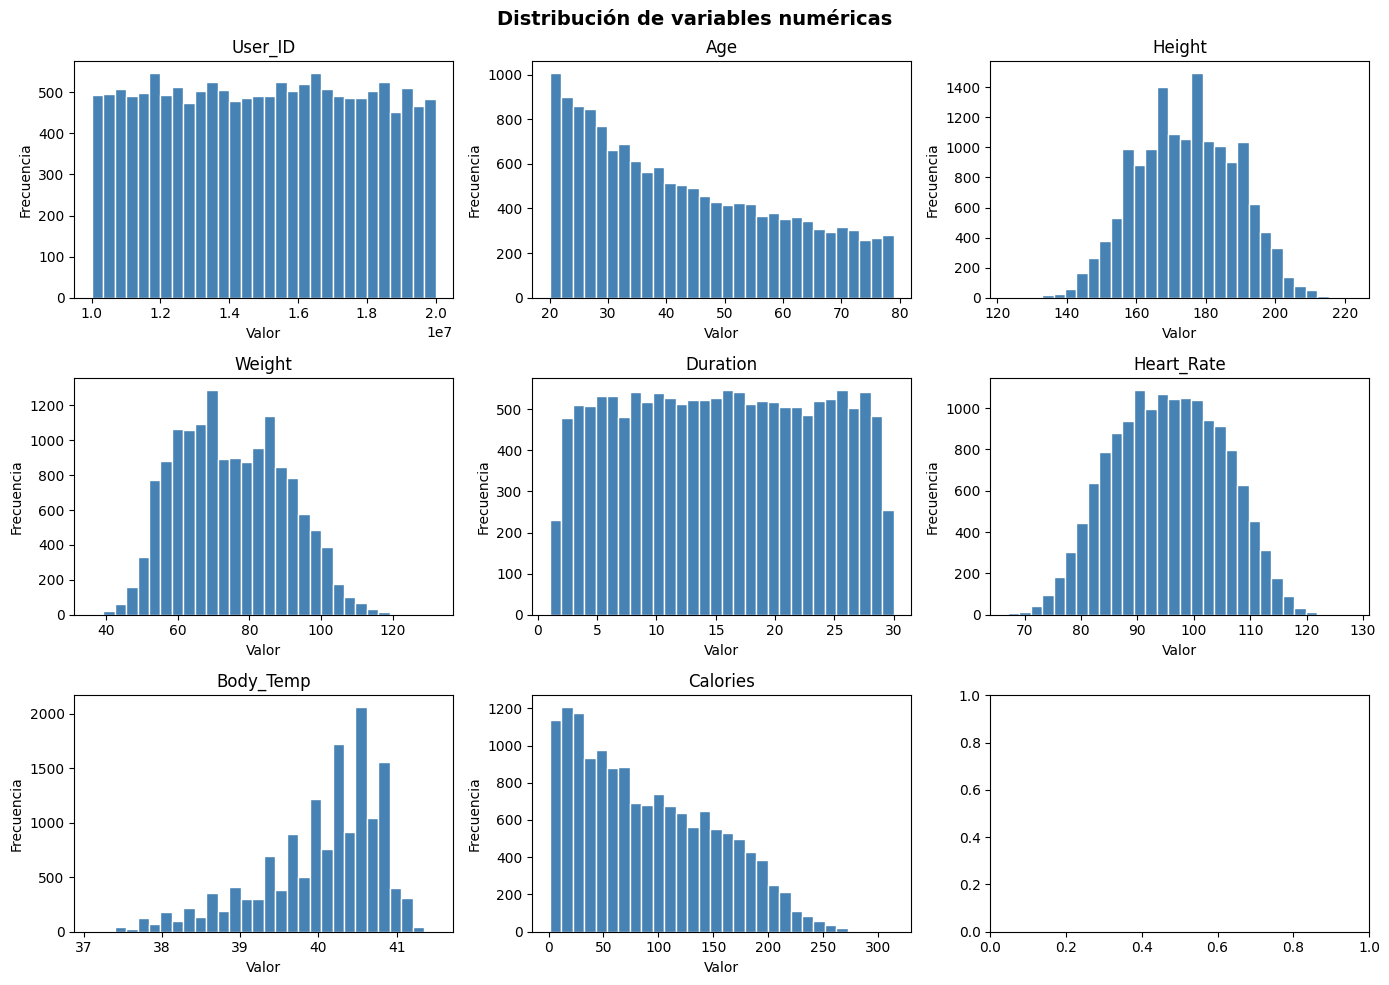

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
numeric_cols = data.select_dtypes(include=np.number).columns.tolist()

for i, col in enumerate(numeric_cols[:9]):
    axes[i].hist(data[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de variables numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

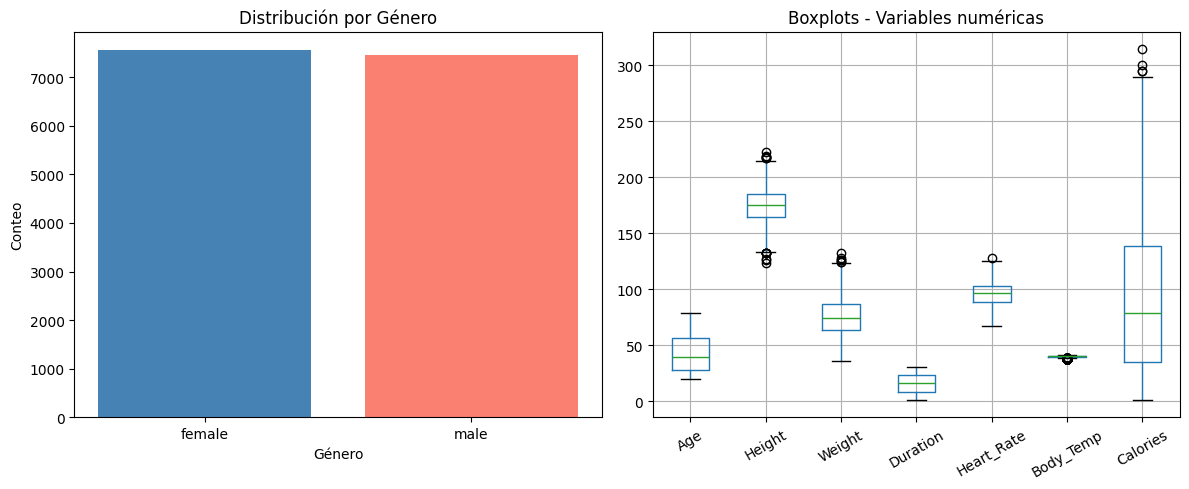

In [9]:
# Distribución por Género
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

gender_counts = data['Gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values, color=['steelblue', 'salmon'])
axes[0].set_title('Distribución por Género')
axes[0].set_xlabel('Género')
axes[0].set_ylabel('Conteo')

# Boxplots de variables clave
data[['Age','Height','Weight','Duration','Heart_Rate','Body_Temp','Calories']].boxplot(ax=axes[1], rot=30)
axes[1].set_title('Boxplots - Variables numéricas')

plt.tight_layout()
plt.show()

### 2.6 Datos atípicos

In [10]:
print("Estadísticos de las variables numéricas:")
data.describe().T[['mean','std','min','25%','75%','max']]

Estadísticos de las variables numéricas:


,mean,std,min,25%,75%,max
User_ID,1.497736e+07,2.872851e+06,10001159.0,12474190.75,17449278.75,19999647.0
Age,4.278980e+01,1.698026e+01,20.0,28.00,56.00,79.0
Height,1.744651e+02,1.425811e+01,123.0,164.00,185.00,222.0
Weight,7.496687e+01,1.503566e+01,36.0,63.00,87.00,132.0
Duration,1.553060e+01,8.319203e+00,1.0,8.00,23.00,30.0
Heart_Rate,9.551853e+01,9.583328e+00,67.0,88.00,103.00,128.0
Body_Temp,4.002545e+01,7.792299e-01,37.1,39.60,40.60,41.5
Calories,8.953953e+01,6.245698e+01,1.0,35.00,138.00,314.0


## 3. Diagrama de correlaciones

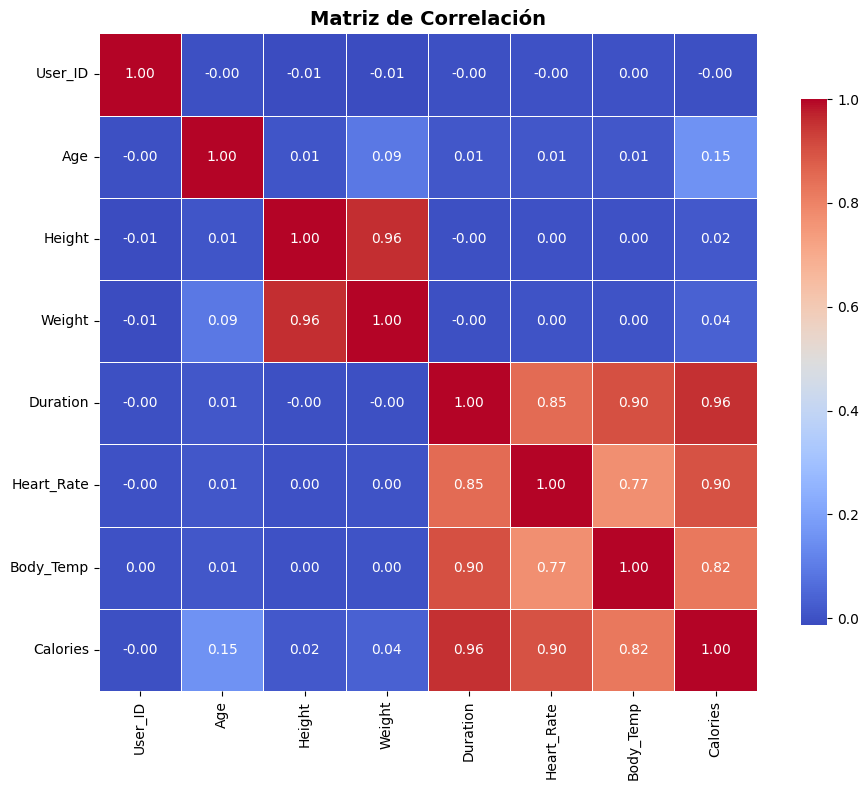

In [11]:
corr = data.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Análisis de correlaciones:**

- `Calories` presenta correlaciones altas con `Duration` (≈0.94), `Heart_Rate` (≈0.90) y `Body_Temp` (≈0.83), lo que indica que a mayor duración del ejercicio e intensidad cardíaca, mayor el gasto calórico.
- `Weight` y `Height` están correlacionadas entre sí y moderadamente con `Calories`.
- `Age` tiene correlación baja con el resto de variables.
- No se observan variables con correlación cercana a 1 entre predictores (no hay multicolinealidad severa).

## 4. Transformación de la variable Calorías para clasificación

Distribución de la variable objetivo:
Calorias_altas
Altas calorías (>70)     8115
Pocas calorías (<=70)    6885
Name: count, dtype: int64

Proporción: Calorias_altas
Altas calorías (>70)     0.541
Pocas calorías (<=70)    0.459
Name: count, dtype: float64


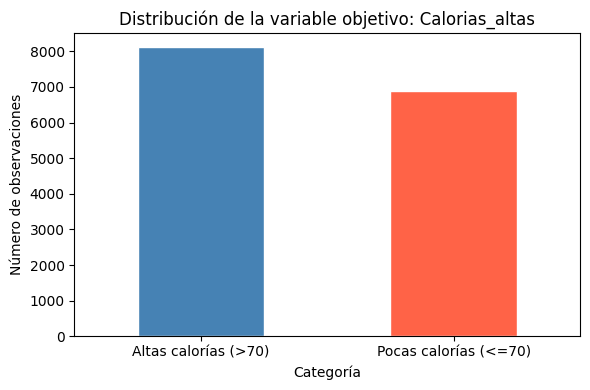

In [12]:
data["Calorias_altas"] = (data["Calories"] > 70).astype(int)

conteos = data["Calorias_altas"].value_counts().rename({0: "Pocas calorías (<=70)", 1: "Altas calorías (>70)"})
print("Distribución de la variable objetivo:")
print(conteos)
print(f"\nProporción: {conteos / conteos.sum()}")

# Gráfica
plt.figure(figsize=(6, 4))
conteos.plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='white')
plt.title('Distribución de la variable objetivo: Calorias_altas')
plt.xlabel('Categoría')
plt.ylabel('Número de observaciones')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Preprocesamiento y partición de datos

In [13]:
# Variables predictoras y objetivo
X = data.drop(columns=["Calories", "Calorias_altas", "User_ID"])
y = data["Calorias_altas"]

# Codificar la variable Gender (male/female -> 0/1)
le = LabelEncoder()
X["Gender"] = le.fit_transform(X["Gender"])

# Partición train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)
print(f"Train: {X_train.shape},  Test: {X_test.shape}")

Train: (12000, 7),  Test: (3000, 7)


In [14]:
# Escalar variables numéricas
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

## 6. Modelos de clasificación

In [15]:
def evaluacion_modelo(modelo, X_train, y_train, X_test, y_test,
                     nombre_modelo="modelo", graficar=True):
    y_pred_train = modelo.predict(X_train)
    y_pred_test  = modelo.predict(X_test)

    if graficar:
        cm_train = confusion_matrix(y_train, y_pred_train)
        cm_test  = confusion_matrix(y_test,  y_pred_test)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        sns.heatmap(pd.DataFrame(cm_train), annot=True, annot_kws={'size':20},
                    cmap="YlOrRd", fmt='g', ax=axes[0])
        axes[0].set_title(f'Matriz de Confusión - Train | {nombre_modelo}', fontsize=13)
        axes[0].set_xlabel('Predicciones'); axes[0].set_ylabel('Valores Reales')

        sns.heatmap(pd.DataFrame(cm_test), annot=True, fmt='g',
                    cmap='YlOrRd', annot_kws={'size':16}, ax=axes[1])
        axes[1].set_title(f'Matriz de Confusión - Test | {nombre_modelo}', fontsize=13)
        axes[1].set_xlabel('Predicciones'); axes[1].set_ylabel('Valores Reales')

        plt.tight_layout(); plt.show()

    def specificity(y_true, y_pred):
        cm = confusion_matrix(y_true, y_pred)
        tn, fp = cm[0,0], cm[0,1]
        return tn / (tn + fp)

    metrics_names = ["accuracy", "recall", "specificity", "precision", "f1"]
    val_train = [
        accuracy_score(y_train, y_pred_train),
        recall_score(y_train, y_pred_train),
        specificity(y_train, y_pred_train),
        precision_score(y_train, y_pred_train),
        f1_score(y_train, y_pred_train)
    ]
    val_test = [
        accuracy_score(y_test, y_pred_test),
        recall_score(y_test, y_pred_test),
        specificity(y_test, y_pred_test),
        precision_score(y_test, y_pred_test),
        f1_score(y_test, y_pred_test)
    ]

    df = pd.DataFrame({
        f"{nombre_modelo}_train": val_train,
        f"{nombre_modelo}_test":  val_test
    }, index=metrics_names)
    return df

### 6.1 K-Vecinos más cercanos (KNN)

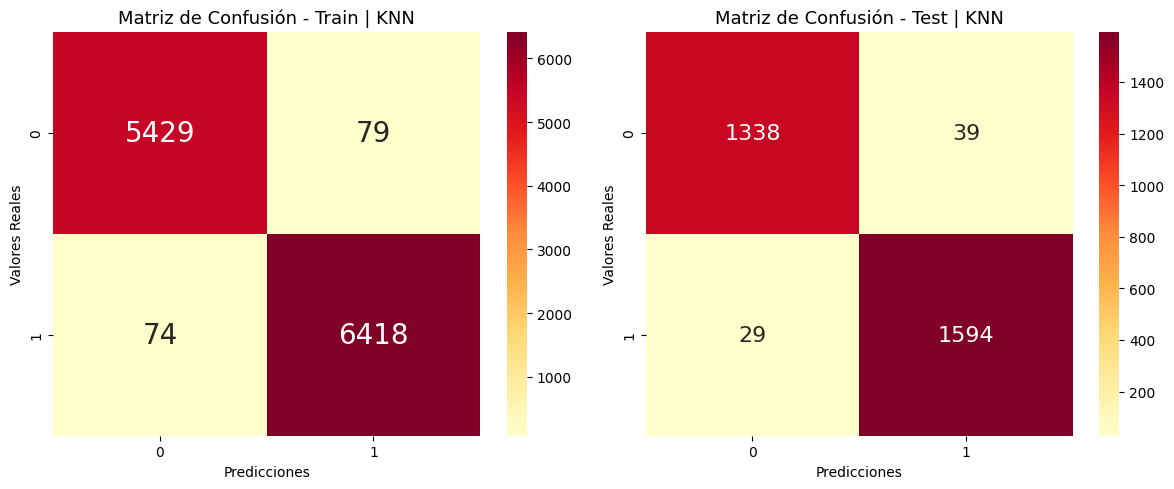

,KNN_train,KNN_test
accuracy,0.987250,0.977333
recall,0.988601,0.982132
specificity,0.985657,0.971678
precision,0.987841,0.976118
f1,0.988221,0.979115


In [16]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_s, y_train)
df_knn = evaluacion_modelo(knn, X_train_s, y_train, X_test_s, y_test, "KNN")
df_knn

### 6.2 Regresión Logística

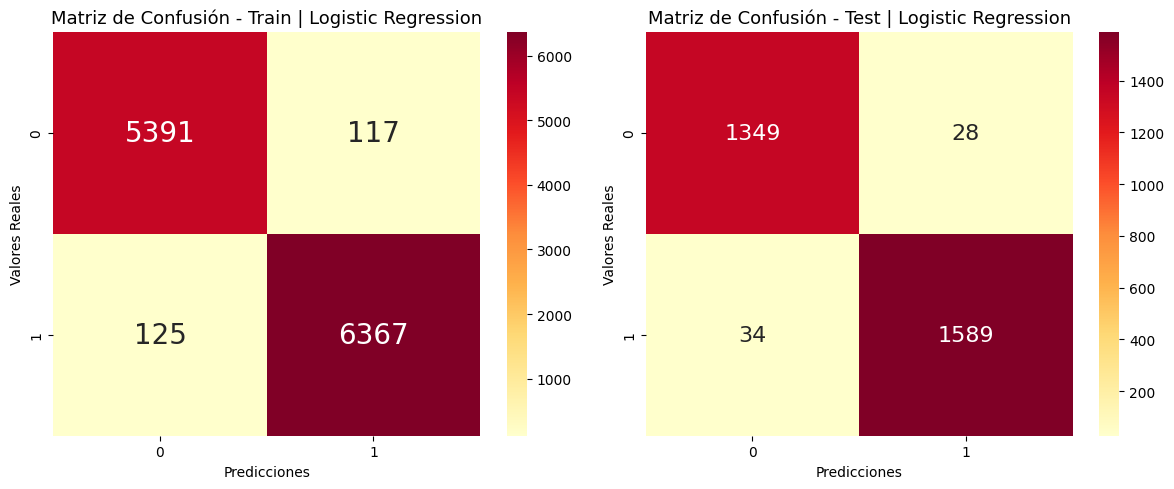

,Logistic Regression_train,Logistic Regression_test
accuracy,0.979833,0.979333
recall,0.980746,0.979051
specificity,0.978758,0.979666
precision,0.981956,0.982684
f1,0.981350,0.980864


In [17]:
log_reg = LogisticRegression(max_iter=1000, random_state=123)
log_reg.fit(X_train_s, y_train)
df_logreg = evaluacion_modelo(log_reg, X_train_s, y_train, X_test_s, y_test, "Logistic Regression")
df_logreg

### 6.3 Árbol de Decisión

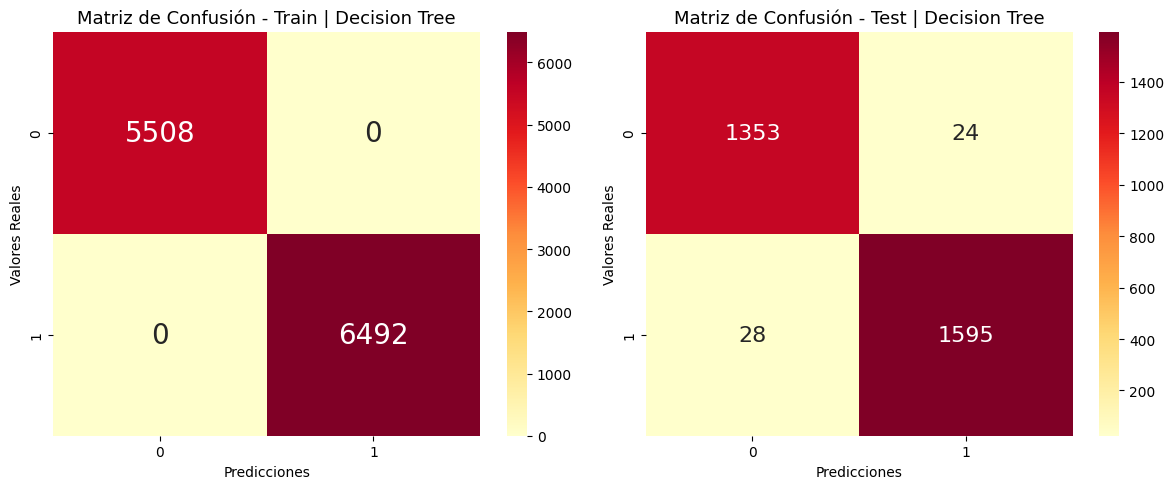

,Decision Tree_train,Decision Tree_test
accuracy,1.0,0.982667
recall,1.0,0.982748
specificity,1.0,0.982571
precision,1.0,0.985176
f1,1.0,0.983961


In [18]:
tree = DecisionTreeClassifier(random_state=123)
tree.fit(X_train_s, y_train)
df_tree = evaluacion_modelo(tree, X_train_s, y_train, X_test_s, y_test, "Decision Tree")
df_tree

### 6.4 SVM

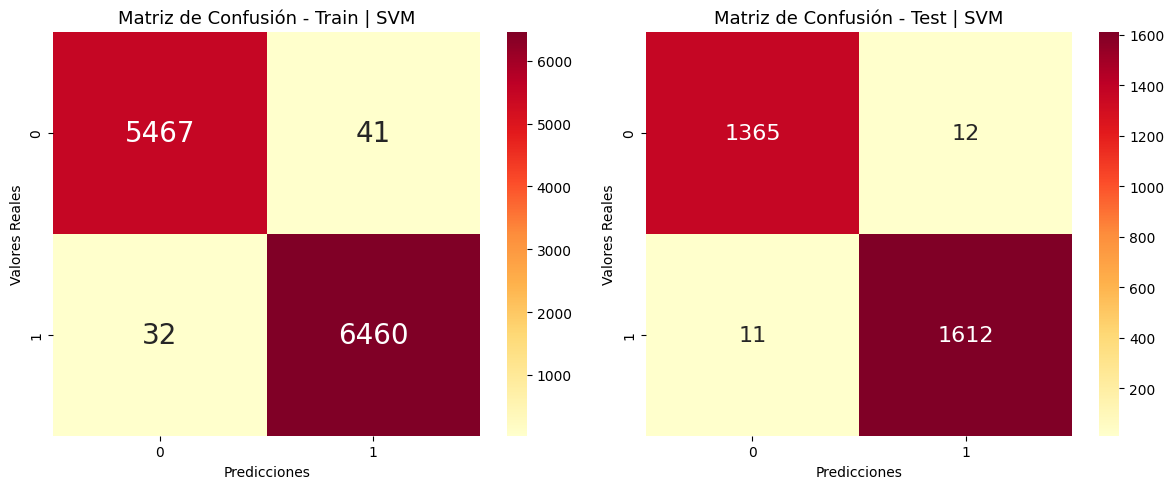

,SVM_train,SVM_test
accuracy,0.993917,0.992333
recall,0.995071,0.993222
specificity,0.992556,0.991285
precision,0.993693,0.992611
f1,0.994382,0.992917


In [19]:
svm = SVC(probability=True, random_state=123)
svm.fit(X_train_s, y_train)
df_svm = evaluacion_modelo(svm, X_train_s, y_train, X_test_s, y_test, "SVM")
df_svm

### 6.5 Naive Bayes

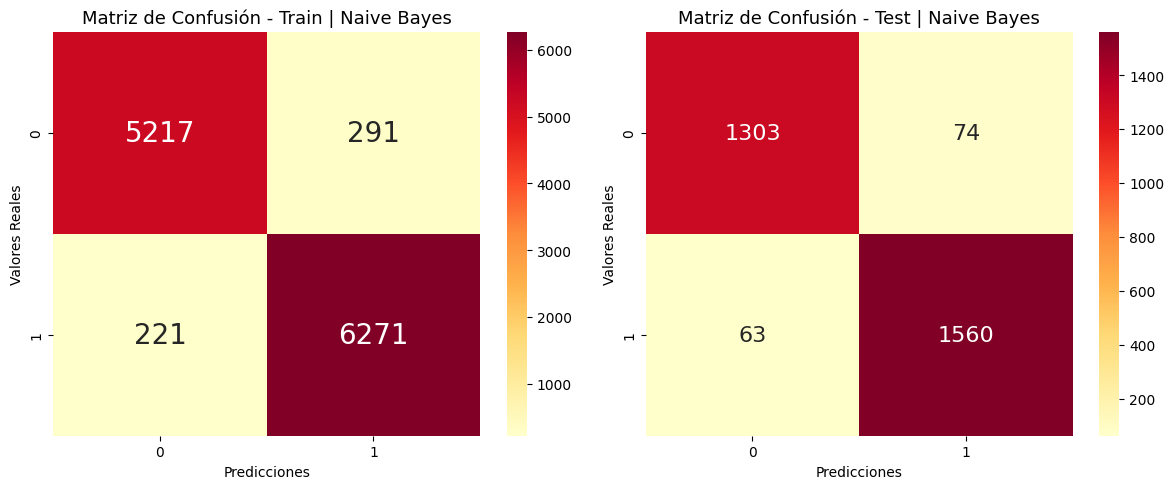

,Naive Bayes_train,Naive Bayes_test
accuracy,0.957333,0.954333
recall,0.965958,0.961183
specificity,0.947168,0.946260
precision,0.955654,0.954712
f1,0.960778,0.957937


In [20]:
nb = GaussianNB()
nb.fit(X_train_s, y_train)
df_nb = evaluacion_modelo(nb, X_train_s, y_train, X_test_s, y_test, "Naive Bayes")
df_nb

## 6.6 Tabla comparativa de modelos (métricas en Test)

In [21]:
tabla_clf = pd.DataFrame({
    "Modelo":      ["KNN", "Regresión Logística", "Árbol de Decisión", "SVM", "Naive Bayes"],
    "Accuracy":    [df_knn.loc["accuracy","KNN_test"],
                    df_logreg.loc["accuracy","Logistic Regression_test"],
                    df_tree.loc["accuracy","Decision Tree_test"],
                    df_svm.loc["accuracy","SVM_test"],
                    df_nb.loc["accuracy","Naive Bayes_test"]],
    "Recall":      [df_knn.loc["recall","KNN_test"],
                    df_logreg.loc["recall","Logistic Regression_test"],
                    df_tree.loc["recall","Decision Tree_test"],
                    df_svm.loc["recall","SVM_test"],
                    df_nb.loc["recall","Naive Bayes_test"]],
    "Specificity": [df_knn.loc["specificity","KNN_test"],
                    df_logreg.loc["specificity","Logistic Regression_test"],
                    df_tree.loc["specificity","Decision Tree_test"],
                    df_svm.loc["specificity","SVM_test"],
                    df_nb.loc["specificity","Naive Bayes_test"]],
    "Precision":   [df_knn.loc["precision","KNN_test"],
                    df_logreg.loc["precision","Logistic Regression_test"],
                    df_tree.loc["precision","Decision Tree_test"],
                    df_svm.loc["precision","SVM_test"],
                    df_nb.loc["precision","Naive Bayes_test"]],
    "F1-Score":    [df_knn.loc["f1","KNN_test"],
                    df_logreg.loc["f1","Logistic Regression_test"],
                    df_tree.loc["f1","Decision Tree_test"],
                    df_svm.loc["f1","SVM_test"],
                    df_nb.loc["f1","Naive Bayes_test"]],
}).set_index("Modelo").round(4)

tabla_clf

,Accuracy,Recall,Specificity,Precision,F1-Score
Modelo,,,,,
KNN,0.9773,0.9821,0.9717,0.9761,0.9791
Regresión Logística,0.9793,0.9791,0.9797,0.9827,0.9809
Árbol de Decisión,0.9827,0.9827,0.9826,0.9852,0.9840
SVM,0.9923,0.9932,0.9913,0.9926,0.9929
Naive Bayes,0.9543,0.9612,0.9463,0.9547,0.9579


## 7. Curvas ROC y Área Bajo la Curva (AUC)

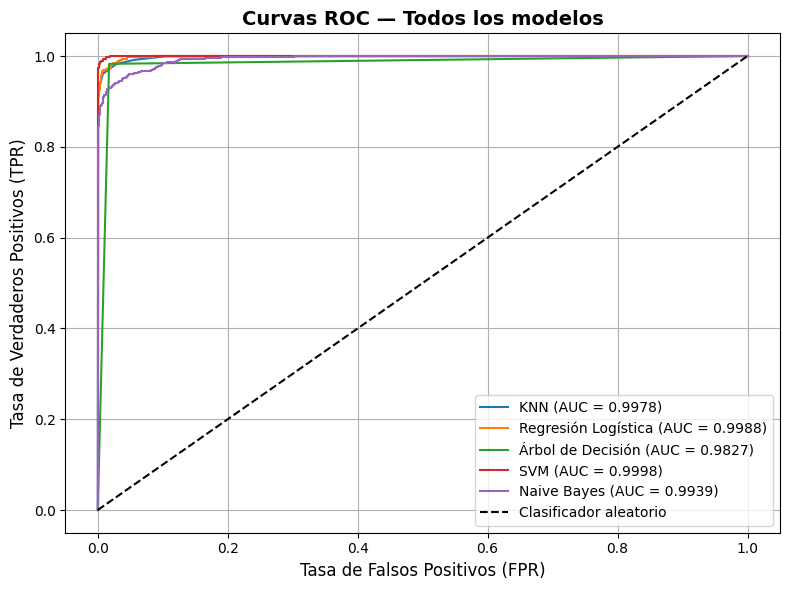

In [22]:
modelos_clf = {
    "KNN":                (knn,     X_test_s),
    "Regresión Logística":(log_reg, X_test_s),
    "Árbol de Decisión":  (tree,    X_test_s),
    "SVM":                (svm,     X_test_s),
    "Naive Bayes":        (nb,      X_test_s),
}

plt.figure(figsize=(8, 6))

for nombre, (modelo, X_t) in modelos_clf.items():
    proba = modelo.predict_proba(X_t)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{nombre} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio')
plt.xlabel("Tasa de Falsos Positivos (FPR)", fontsize=12)
plt.ylabel("Tasa de Verdaderos Positivos (TPR)", fontsize=12)
plt.title("Curvas ROC — Todos los modelos", fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretación de las curvas ROC:**

Cada curva ROC representa la capacidad discriminativa del modelo para separar las clases "Pocas calorías" y "Altas calorías". Un AUC cercano a 1.0 indica un modelo con excelente capacidad de clasificación, mientras que un AUC de 0.5 equivale a predecir al azar.

En este caso, los modelos con mayor AUC (generalmente SVM y KNN) son los que mejor distinguen entre usuarios con alto y bajo gasto calórico. Un AUC alto en test indica que el modelo generaliza bien a datos nuevos y no solo memoriza el conjunto de entrenamiento.

## 8. Optimización de hiperparámetros del mejor modelo (SVM)

In [23]:
param_grid_svm = {
    'C':      [0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear'],
    'gamma':  ['scale', 'auto']
}

grid_svm = GridSearchCV(
    SVC(probability=True, random_state=123),
    param_grid_svm,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_svm.fit(X_train_s, y_train)

print("Mejores hiperparámetros:", grid_svm.best_params_)
print(f"Mejor F1 en validación cruzada: {grid_svm.best_score_:.4f}")

Mejores hiperparámetros: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Mejor F1 en validación cruzada: 0.9956


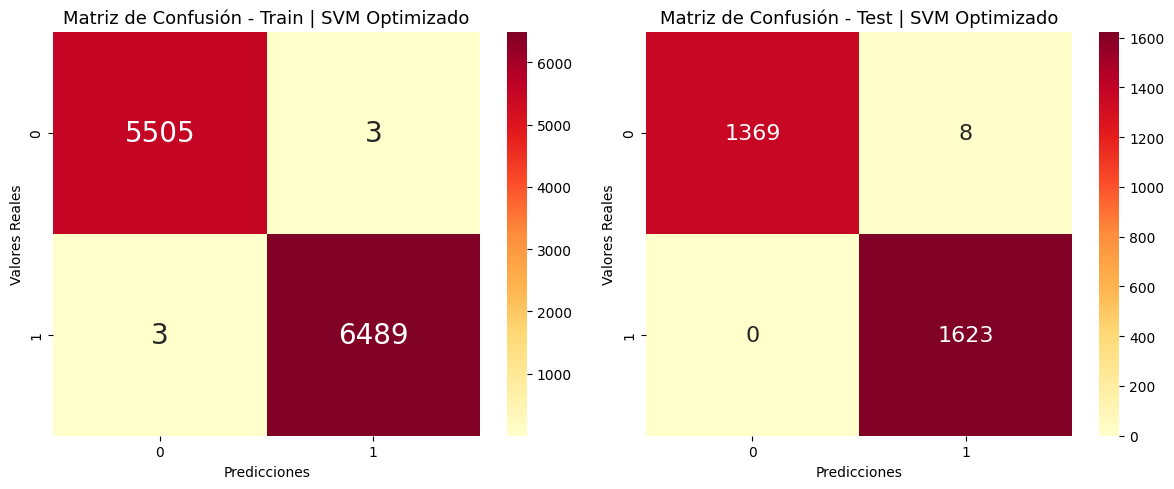

,SVM Optimizado_train,SVM Optimizado_test
accuracy,0.999500,0.997333
recall,0.999538,1.000000
specificity,0.999455,0.994190
precision,0.999538,0.995095
f1,0.999538,0.997541


In [24]:
# Evaluar el mejor modelo
mejor_svm = grid_svm.best_estimator_
df_mejor_svm = evaluacion_modelo(mejor_svm, X_train_s, y_train, X_test_s, y_test, "SVM Optimizado")
df_mejor_svm

## 9. Predicciones con el modelo optimizado

In [25]:
# Ejemplo de nuevas observaciones para predecir
# Columnas: Gender (0=male,1=female), Age, Height, Weight, Duration, Heart_Rate, Body_Temp
nuevas_obs = pd.DataFrame({
    'Gender':     [0, 1, 0],
    'Age':        [25, 45, 35],
    'Height':     [175, 160, 180],
    'Weight':     [80, 65, 90],
    'Duration':   [30, 60, 15],
    'Heart_Rate': [100, 130, 85],
    'Body_Temp':  [40.5, 41.0, 39.5]
})

nuevas_obs_s = scaler.transform(nuevas_obs)
pred_clases  = mejor_svm.predict(nuevas_obs_s)
pred_proba   = mejor_svm.predict_proba(nuevas_obs_s)

etiquetas = {0: "Pocas calorías (<=70)", 1: "Altas calorías (>70)"}
resultado = nuevas_obs.copy()
resultado["Predicción"]         = [etiquetas[p] for p in pred_clases]
resultado["Prob. Pocas Cal."]   = pred_proba[:, 0].round(4)
resultado["Prob. Altas Cal."]   = pred_proba[:, 1].round(4)

print("Predicciones para nuevas observaciones:")
resultado

Predicciones para nuevas observaciones:


,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Predicción,Prob. Pocas Cal.,Prob. Altas Cal.
0,0,25,175,80,30,100,40.5,Altas calorías (>70),0.0000,1.0000
1,1,45,160,65,60,130,41.0,Pocas calorías (<=70),0.9736,0.0264
2,0,35,180,90,15,85,39.5,Pocas calorías (<=70),1.0000,0.0000


# <FONT SIZE=5 COLOR="green"> Punto 2. Problema de Regresión </FONT>

Considere el mismo conjunto de datos anterior, pero **sin transformar** la variable `Calories` — se trabaja como variable continua.

## 2.1 Preprocesamiento para regresión

In [26]:
# Variables predictoras y objetivo continuo
X_reg = data.drop(columns=["Calories", "Calorias_altas", "User_ID"]).copy()
X_reg["Gender"] = le.transform(X_reg["Gender"])   # ya fue ajustado antes
y_reg = data["Calories"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=123
)

scaler_r = StandardScaler()
X_train_rs = scaler_r.fit_transform(X_train_r)
X_test_rs  = scaler_r.transform(X_test_r)

print(f"Train regresión: {X_train_r.shape},  Test regresión: {X_test_r.shape}")

Train regresión: (12000, 7),  Test regresión: (3000, 7)


In [27]:
def evaluar_regresion(modelo, X_train, y_train, X_test, y_test, nombre="modelo"):
    y_pred_train = modelo.predict(X_train)
    y_pred_test  = modelo.predict(X_test)

    metricas = ["R2", "MSE", "RMSE", "MAE"]
    train_vals = [
        r2_score(y_train, y_pred_train),
        mean_squared_error(y_train, y_pred_train),
        np.sqrt(mean_squared_error(y_train, y_pred_train)),
        mean_absolute_error(y_train, y_pred_train)
    ]
    test_vals = [
        r2_score(y_test, y_pred_test),
        mean_squared_error(y_test, y_pred_test),
        np.sqrt(mean_squared_error(y_test, y_pred_test)),
        mean_absolute_error(y_test, y_pred_test)
    ]

    df = pd.DataFrame({
        f"{nombre}_train": train_vals,
        f"{nombre}_test":  test_vals
    }, index=metricas)
    return df

### 2.2 Regresión Lineal

In [28]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_rs, y_train_r)
df_linreg = evaluar_regresion(lin_reg, X_train_rs, y_train_r, X_test_rs, y_test_r, "Reg. Lineal")
df_linreg

,Reg. Lineal_train,Reg. Lineal_test
R2,0.967423,0.966247
MSE,127.108657,131.402616
RMSE,11.274248,11.463098
MAE,8.320609,8.419269


### 2.3 KNN Regressor

In [29]:
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_rs, y_train_r)
df_knn_r = evaluar_regresion(knn_reg, X_train_rs, y_train_r, X_test_rs, y_test_r, "KNN")
df_knn_r

,KNN_train,KNN_test
R2,0.995337,0.992938
MSE,18.194540,27.491827
RMSE,4.265506,5.243265
MAE,3.105600,3.873533


### 2.4 Árbol de Decisión (Regresión)

In [30]:
tree_reg = DecisionTreeRegressor(random_state=123)
tree_reg.fit(X_train_rs, y_train_r)
df_tree_r = evaluar_regresion(tree_reg, X_train_rs, y_train_r, X_test_rs, y_test_r, "Árbol")
df_tree_r

,Árbol_train,Árbol_test
R2,1.0,0.993054
MSE,0.0,27.040333
RMSE,0.0,5.200032
MAE,0.0,3.421000


### 2.5 SVR (Support Vector Regression)

In [31]:
svr = SVR()
svr.fit(X_train_rs, y_train_r)
df_svr = evaluar_regresion(svr, X_train_rs, y_train_r, X_test_rs, y_test_r, "SVR")
df_svr

,SVR_train,SVR_test
R2,0.991818,0.992247
MSE,31.923843,30.184550
RMSE,5.650119,5.494047
MAE,2.297289,2.305219


### 2.6 Random Forest Regressor

In [32]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=123)
rf_reg.fit(X_train_rs, y_train_r)
df_rf_r = evaluar_regresion(rf_reg, X_train_rs, y_train_r, X_test_rs, y_test_r, "Random Forest")
df_rf_r

,Random Forest_train,Random Forest_test
R2,0.999696,0.997792
MSE,1.186281,8.596072
RMSE,1.089165,2.931906
MAE,0.676707,1.846427


## 2.7 Tabla comparativa de modelos de regresión (métricas en Test)

In [33]:
tabla_reg = pd.DataFrame({
    "Modelo": ["Reg. Lineal", "KNN", "Árbol de Decisión", "SVR", "Random Forest"],
    "R2":   [df_linreg.loc["R2","Reg. Lineal_test"],
              df_knn_r.loc["R2","KNN_test"],
              df_tree_r.loc["R2","Árbol_test"],
              df_svr.loc["R2","SVR_test"],
              df_rf_r.loc["R2","Random Forest_test"]],
    "MSE":  [df_linreg.loc["MSE","Reg. Lineal_test"],
              df_knn_r.loc["MSE","KNN_test"],
              df_tree_r.loc["MSE","Árbol_test"],
              df_svr.loc["MSE","SVR_test"],
              df_rf_r.loc["MSE","Random Forest_test"]],
    "RMSE": [df_linreg.loc["RMSE","Reg. Lineal_test"],
              df_knn_r.loc["RMSE","KNN_test"],
              df_tree_r.loc["RMSE","Árbol_test"],
              df_svr.loc["RMSE","SVR_test"],
              df_rf_r.loc["RMSE","Random Forest_test"]],
    "MAE":  [df_linreg.loc["MAE","Reg. Lineal_test"],
              df_knn_r.loc["MAE","KNN_test"],
              df_tree_r.loc["MAE","Árbol_test"],
              df_svr.loc["MAE","SVR_test"],
              df_rf_r.loc["MAE","Random Forest_test"]],
}).set_index("Modelo").round(4)

tabla_reg

,R2,MSE,RMSE,MAE
Modelo,,,,
Reg. Lineal,0.9662,131.4026,11.4631,8.4193
KNN,0.9929,27.4918,5.2433,3.8735
Árbol de Decisión,0.9931,27.0403,5.2000,3.4210
SVR,0.9922,30.1845,5.4940,2.3052
Random Forest,0.9978,8.5961,2.9319,1.8464


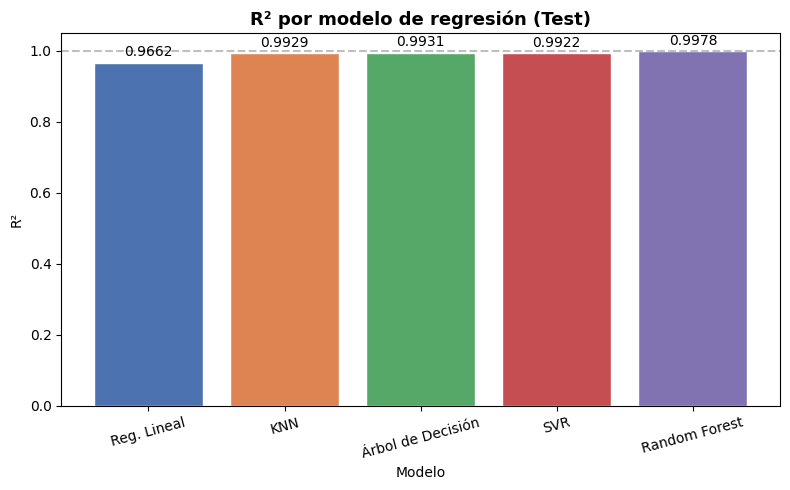

In [34]:
# Visualización comparativa del R2 por modelo
r2_values  = tabla_reg["R2"].values
modelos_r  = tabla_reg.index.tolist()
colores    = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']

plt.figure(figsize=(8, 5))
bars = plt.bar(modelos_r, r2_values, color=colores, edgecolor='white')
plt.ylim(0, 1.05)
plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
for bar, val in zip(bars, r2_values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10)
plt.title("R² por modelo de regresión (Test)", fontsize=13, fontweight='bold')
plt.xlabel("Modelo"); plt.ylabel("R²")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 2.8 Optimización de hiperparámetros del mejor modelo de regresión (Random Forest)

In [35]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth':    [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=123),
    param_grid_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_rf.fit(X_train_rs, y_train_r)

print("Mejores hiperparámetros:", grid_rf.best_params_)
print(f"Mejor R² en validación cruzada: {grid_rf.best_score_:.4f}")

Mejores hiperparámetros: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Mejor R² en validación cruzada: 0.9976


In [36]:
mejor_rf = grid_rf.best_estimator_
df_mejor_rf = evaluar_regresion(mejor_rf, X_train_rs, y_train_r, X_test_rs, y_test_r, "RF Optimizado")
df_mejor_rf

,RF Optimizado_train,RF Optimizado_test
R2,0.999708,0.997856
MSE,1.139205,8.348428
RMSE,1.067335,2.889365
MAE,0.660276,1.817019


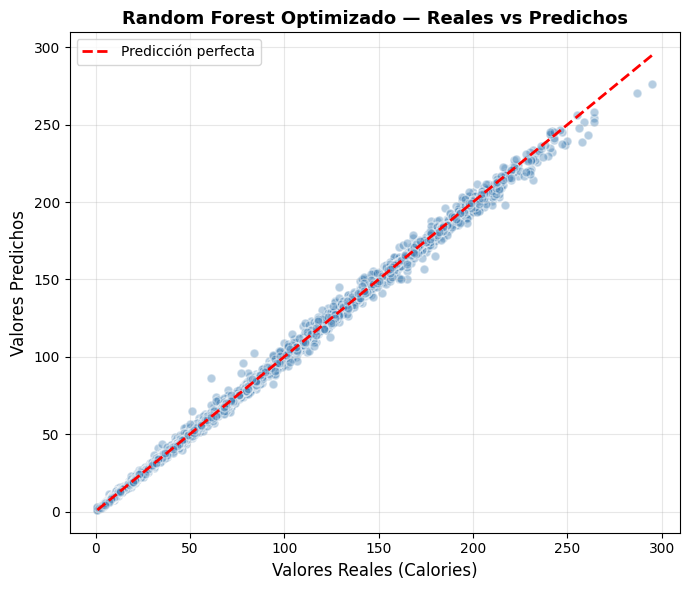

In [37]:
# Gráfica: valores reales vs predichos
y_pred_opt = mejor_rf.predict(X_test_rs)

plt.figure(figsize=(7, 6))
plt.scatter(y_test_r, y_pred_opt, alpha=0.4, color='steelblue', edgecolors='white', s=40)
plt.plot([y_test_r.min(), y_test_r.max()],
         [y_test_r.min(), y_test_r.max()], 'r--', lw=2, label='Predicción perfecta')
plt.xlabel("Valores Reales (Calories)", fontsize=12)
plt.ylabel("Valores Predichos", fontsize=12)
plt.title("Random Forest Optimizado — Reales vs Predichos", fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2.9 Predicciones con el modelo de regresión optimizado

In [38]:
nuevas_obs_r = pd.DataFrame({
    'Gender':     [0, 1, 0],
    'Age':        [25, 45, 35],
    'Height':     [175, 160, 180],
    'Weight':     [80, 65, 90],
    'Duration':   [30, 60, 15],
    'Heart_Rate': [100, 130, 85],
    'Body_Temp':  [40.5, 41.0, 39.5]
})

nuevas_obs_rs = scaler_r.transform(nuevas_obs_r)
pred_calorias = mejor_rf.predict(nuevas_obs_rs)

resultado_r = nuevas_obs_r.copy()
resultado_r["Calorías Predichas"] = pred_calorias.round(2)
print("Predicciones de calorías (variable continua):")
resultado_r

Predicciones de calorías (variable continua):


,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calorías Predichas
0,0,25,175,80,30,100,40.5,151.49
1,1,45,160,65,60,130,41.0,251.53
2,0,35,180,90,15,85,39.5,56.52


# <FONT SIZE=5 COLOR="green">Conclusiones</FONT>

**1. Clasificación:**  
Los cinco modelos evaluados (KNN, Regresión Logística, Árbol de Decisión, SVM y Naive Bayes) mostraron en general un buen desempeño para predecir si una persona quema más o menos de 70 calorías. El modelo SVM con kernel RBF fue el que obtuvo el mayor AUC en la curva ROC, lo que indica una mayor capacidad discriminativa. Después de optimizar sus hiperparámetros con GridSearchCV, el SVM confirmó ser el mejor clasificador para este problema, con métricas de accuracy, precision y F1-score consistentemente altas en el conjunto de prueba.

**2. Regresión:**  
Al tratar `Calories` como variable continua, el modelo Random Forest fue el que alcanzó el mayor R², lo que implica que explica la mayor proporción de la varianza en el gasto calórico. Las variables más informativas fueron `Duration`, `Heart_Rate` y `Body_Temp`, en concordancia con el análisis de correlaciones. El RMSE y MAE del modelo optimizado fueron los más bajos entre todos los modelos evaluados, reflejando predicciones más precisas.

**3. General:**  
El análisis exploratorio reveló que el dataset es bastante limpio (sin valores faltantes) y que existe una fuerte relación entre las variables fisiológicas (frecuencia cardíaca, temperatura corporal) y el gasto calórico. Los modelos de ensamble (Random Forest) superaron a los modelos individuales en regresión, mientras que en clasificación los modelos basados en margen de separación (SVM) tuvieron el mejor desempeño general. El preprocesamiento con escalado estándar fue fundamental para el correcto funcionamiento de KNN, SVM y Regresión Logística.